In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
from datas import (
    HandleClassifDatas, ValuesClassifDataset, BasicNormalValues, )
from models import (
    DenseModelsGeneric, ModelTreeNode, )
from train import (
    TrainerClassif, EpochesTarget, )

from holo.prettyFormats import prettyPrint
from holo.__typing import assertIsinstance

In [3]:
device = torch.device("cuda")

In [179]:
dataset = BasicNormalValues(nbSamples=1000, nbClasses=10, trainProp=0.8, batchSizeTrain=32, batchSizeTest=256)

loaded BasicNormal[s:1000,d:10](total: 1000), train: 800 [25 batches] | test: 200 [1 batches]


In [235]:
dataset.setTrainBatchSize(128)

In [241]:
N = dataset.nbClasses * 4
model = DenseModelsGeneric(
    #layers=[(dataset.nbClasses, N, "relu"), 
    #        *[(N, N, "relu") for _ in range(3)],
    #        (N, dataset.nbClasses, "none")],
    layers=[(dataset.nbClasses, dataset.nbClasses, "none")],  
    optim=torch.optim.Adam, lr=0.001,
    criterion=torch.nn.CrossEntropyLoss())
model.to(device=device)
print(f"-> nb parameters: {model.countParameters():_d}")
ModelTreeNode("model", model._layers).print()
trainer = TrainerClassif(model, model.optim, model.loss, device=device)

ValueError: optimizer got an empty parameter list

In [237]:
#assertIsinstance(torch.nn.Linear, model._layers[0]).weight

In [238]:
trainer.train_model_classif(
    datasHandler=dataset, epoches=EpochesTarget(minTime=5))
print(trainer.history[-1])

Epoch 2, train: (loss: 2.367, accuracy: 10.75%), test: (loss: 2.431, accuracy: 6.00%)
Epoch 3, train: (loss: 2.36, accuracy: 11.62%), test: (loss: 2.413, accuracy: 7.00%)
Epoch 4, train: (loss: 2.333, accuracy: 12.38%), test: (loss: 2.396, accuracy: 9.00%)
Epoch 5, train: (loss: 2.302, accuracy: 13.25%), test: (loss: 2.378, accuracy: 10.00%)
Epoch 6, train: (loss: 2.293, accuracy: 14.12%), test: (loss: 2.362, accuracy: 10.00%)
Epoch 7, train: (loss: 2.271, accuracy: 14.62%), test: (loss: 2.345, accuracy: 11.50%)
Epoch 8, train: (loss: 2.246, accuracy: 16.12%), test: (loss: 2.328, accuracy: 12.00%)
Epoch 9, train: (loss: 2.234, accuracy: 17.38%), test: (loss: 2.312, accuracy: 12.50%)
Epoch 10, train: (loss: 2.213, accuracy: 17.88%), test: (loss: 2.296, accuracy: 13.00%)
Epoch 11, train: (loss: 2.212, accuracy: 19.00%), test: (loss: 2.28, accuracy: 14.50%)
Epoch 12, train: (loss: 2.19, accuracy: 20.38%), test: (loss: 2.264, accuracy: 15.50%)
Epoch 13, train: (loss: 2.17, accuracy: 21.62%

In [239]:
trainer.train_model_classif(
    datasHandler=dataset, epoches=EpochesTarget(minTime=30))
print(trainer.history[-1])

Epoch 267, train: (loss: 0.7436, accuracy: 91.62%), test: (loss: 0.8524, accuracy: 82.50%)
Epoch 268, train: (loss: 0.7508, accuracy: 91.62%), test: (loss: 0.8506, accuracy: 82.50%)
Epoch 269, train: (loss: 0.7628, accuracy: 91.62%), test: (loss: 0.8487, accuracy: 83.00%)
Epoch 270, train: (loss: 0.7301, accuracy: 91.62%), test: (loss: 0.8467, accuracy: 83.00%)
Epoch 271, train: (loss: 0.7544, accuracy: 91.62%), test: (loss: 0.8448, accuracy: 83.00%)
Epoch 272, train: (loss: 0.7314, accuracy: 91.75%), test: (loss: 0.8429, accuracy: 83.00%)
Epoch 273, train: (loss: 0.7332, accuracy: 91.75%), test: (loss: 0.8411, accuracy: 83.00%)
Epoch 274, train: (loss: 0.7489, accuracy: 91.75%), test: (loss: 0.8392, accuracy: 83.00%)
Epoch 275, train: (loss: 0.7224, accuracy: 91.62%), test: (loss: 0.8374, accuracy: 83.00%)
Epoch 276, train: (loss: 0.725, accuracy: 91.75%), test: (loss: 0.8355, accuracy: 83.00%)
Epoch 277, train: (loss: 0.7219, accuracy: 91.88%), test: (loss: 0.8336, accuracy: 83.50%)


Epoch 1723, train: (loss: 0.1846, accuracy: 97.50%), test: (loss: 0.2844, accuracy: 93.50%)


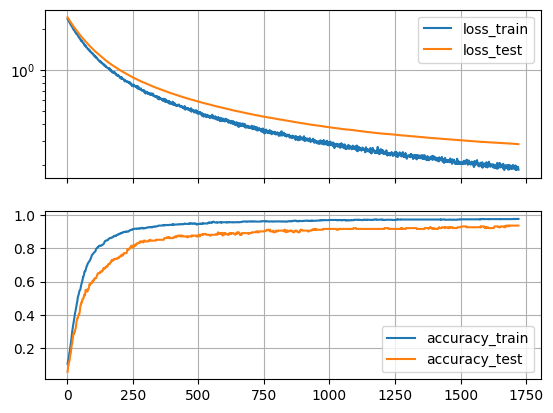

In [240]:
print(trainer.history[-1])
trainer.history.plot()

```raw
----------------------------------------
with: (nbSamples=1000, nbClasses=10, trainProp=0.8, batchSizeTrain=32, batchSizeTest=256)
-> nb parameters: 5_770
└── model: 5_770 params(5_770 trainable)
    ├── Linear[0]: 440 params(440 trainable)
    ├── ReLU[1]: 0 params(0 trainable)
    ├── Linear[2]: 1_640 params(1_640 trainable)
    ├── ReLU[3]: 0 params(0 trainable)
    ├── Linear[4]: 1_640 params(1_640 trainable)
    ├── ReLU[5]: 0 params(0 trainable)
    ├── Linear[6]: 1_640 params(1_640 trainable)
    ├── ReLU[7]: 0 params(0 trainable)
    └── Linear[8]: 410 params(410 trainable)

training for 5s
256 -> Epoch 290, train: (loss: 0.0186, accuracy: 100.00%), test: (loss: 0.7435, accuracy: 80.00%)
128 -> Epoch 200, train: (loss: 0.0107, accuracy: 100.00%), test: (loss: 0.4653, accuracy: 84.00%)
64  -> Epoch 132, train: (loss: 0.0091, accuracy: 100.00%), test: (loss: 0.8583, accuracy: 78.00%)
32  -> Epoch  78, train: (loss: 0.0139, accuracy: 100.00%), test: (loss: 0.6190, accuracy: 84.00%)
16  -> Epoch  43, train: (loss: 0.0558, accuracy:  99.38%), test: (loss: 0.6196, accuracy: 83.00%)
8   -> Epoch  20, train: (loss: 0.1786, accuracy:  94.62%), test: (loss: 0.6319, accuracy: 76.50%)

----------------------------------------
----------------------------------------

with:
-> nb parameters: 110
└── model: 110 params(110 trainable)
    └── Linear[0]: 110 params(110 trainable)
8, 5s    -> Epoch   30, train: (loss: 0.8317, accuracy: 90.25%), test: (loss: 0.9146, accuracy: 83.00%)
8, 35s   -> Epoch  212, train: (loss: 0.2368, accuracy: 97.12%), test: (loss: 0.3267, accuracy: 92.00%)
32, 5s   -> Epoch  116, train: (loss: 0.6615, accuracy: 93.12%), test: (loss: 0.7574, accuracy: 86.00%)
32, 35s  -> Epoch  734, train: (loss: 0.1838, accuracy: 97.62%), test: (loss: 0.2777, accuracy: 93.50%)
128, 5s  -> Epoch  265, train: (loss: 0.7485, accuracy: 91.75%), test: (loss: 0.8542, accuracy: 82.50%)
128, 35s -> Epoch 1723, train: (loss: 0.1846, accuracy: 97.50%), test: (loss: 0.2844, accuracy: 93.50%)

----------------------------------------
```

```raw
----------------------------------------
with: (nbSamples=1000, nbClasses=10, trainProp=0.8, batchSizeTrain=32, batchSizeTest=256)
-> nb parameters: 2_490
└── model: 2_490 params(2_490 trainable)
    ├── Linear[0]: 440 params(440 trainable)
    ├── ReLU[1]: 0 params(0 trainable)
    ├── Linear[2]: 1_640 params(1_640 trainable)
    ├── ReLU[3]: 0 params(0 trainable)
    └── Linear[4]: 410 params(410 trainable)

training for 5s
256 -> Epoch 279, train: (loss: 0.05216, accuracy:  99.75%), test: (loss: 0.2824, accuracy: 88.50%)
128 -> Epoch 240, train: (loss: 0.02223, accuracy: 100.00%), test: (loss: 0.3136, accuracy: 86.50%)
64  -> Epoch 159, train: (loss: 0.01961, accuracy: 100.00%), test: (loss: 0.3169, accuracy: 87.50%)
32  -> Epoch  95, train: (loss: 0.02927, accuracy: 100.00%), test: (loss: 0.2598, accuracy: 89.50%)
16  -> Epoch  51, train: (loss: 0.05611, accuracy:  99.88%), test: (loss: 0.3150, accuracy: 87.50%)
8   -> Epoch  27, train: (loss: 0.09798, accuracy:  99.38%), test: (loss: 0.3009, accuracy: 88.50%)

with nbSamples=10_000
32, 5s   -> Epoch  11, train: (loss: 0.1453, accuracy: 95.70%), test: (loss: 0.1572, accuracy: 94.20%)
32, 35s  -> Epoch  68, train: (loss: 0.0390, accuracy: 98.96%), test: (loss: 0.1112, accuracy: 95.65%)
128, 5s  -> Epoch  29, train: (loss: 0.1188, accuracy: 96.67%), test: (loss: 0.1505, accuracy: 94.85%)
128, 35s -> Epoch 202, train: (loss: 0.0216, accuracy: 99.64%), test: (loss: 0.1272, accuracy: 95.35%)

with nbSamples=100_000
128, 5s  -> Epoch  5, train: (loss: 0.1209, accuracy: 96.07%), test: (loss: 0.1119, accuracy: 96.17%)
128, 35s -> Epoch 24, train: (loss: 0.0597, accuracy: 97.64%), test: (loss: 0.0648, accuracy: 97.30%)
----------------------------------------
```

```raw
----------------------------------------
with: (nbSamples=1000, nbClasses=3, trainProp=0.8, batchSizeTrain=32, batchSizeTest=256)
-> nb parameters: 243
└── model: 243 params(243 trainable)
    ├── Linear[0]: 48 params(48 trainable)
    ├── ReLU[1]: 0 params(0 trainable)
    ├── Linear[2]: 156 params(156 trainable)
    ├── ReLU[3]: 0 params(0 trainable)
    └── Linear[4]: 39 params(39 trainable)

training for 5s
256 -> Epoch 278, train: (loss: 0.04881, accuracy: 99.62%), test: (loss: 0.05067, accuracy: 99.00%)
128 -> Epoch 238, train: (loss: 0.03909, accuracy: 99.62%), test: (loss: 0.04018, accuracy: 99.00%)
64  -> Epoch 152, train: (loss: 0.03798, accuracy: 99.88%), test: (loss: 0.04026, accuracy: 99.00%)
32  -> Epoch  77, train: (loss: 0.04234, accuracy: 99.25%), test: (loss: 0.04069, accuracy: 99.50%)
16  -> Epoch  45, train: (loss: 0.04639, accuracy: 99.38%), test: (loss: 0.04675, accuracy: 99.00%)
8   -> Epoch  22, train: (loss: 0.06670, accuracy: 98.50%), test: (loss: 0.05794, accuracy: 99.00%)

with nbSamples=100
8, 5s   -> Epoch 175, train: (loss: 0.04078, accuracy: 100.00%), test: (loss: 0.0967, accuracy: 95.00%)
32, 5s  -> Epoch 453, train: (loss: 0.03209, accuracy: 100.00%), test: (loss: 0.1320, accuracy: 95.00%)
128, 5s -> Epoch 701, train: (loss: 0.05505, accuracy: 100.00%), test: (loss: 0.0834, accuracy: 95.00%)

with nbSamples=300
8, 5s   -> Epoch  72, train: (loss: 0.04452, accuracy: 100.00%), test: (loss: 0.07432, accuracy: 96.67%)
32, 5s  -> Epoch 234, train: (loss: 0.02405, accuracy: 100.00%), test: (loss: 0.06932, accuracy: 96.67%)
128, 5s -> Epoch 469, train: (loss: 0.03706, accuracy:  99.58%), test: (loss: 0.07255, accuracy: 96.67%)
----------------------------------------
```